In [4]:
import json

import colorcet
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.stats

from lib.plots import set_axis, attach_colorbar, kde1d_at
from lib.stats import fit_power_law

In [5]:
task_id = "task-4"

metrics_table = pl.read_csv(f"{task_id}/metrics.csv")

with open(f"{task_id}/config_template.json") as file:
    config_template = json.load(file)

In [41]:
sweep_ranges = config_template["@meta"]["sweep_ranges"]

key_label = {
    "extruder_diffusivity":      "Diffusivity, " + r"$ k_\mathrm{D} $ ($ \tau^{-1} $)",
    "extruder_speed":            r"$ k_\mathrm{v} $ ($ \tau^{-1} $)",
    "extruder_loading_constant": "Loading const.\n" + r"$ K_\mathrm{load} $",
    "extruder_crossing_factor":  r"$ \alpha_\mathrm{cross} $",
    "msd_alpha":                 "MSD exp., " + r"$ \alpha $",
    "msd_alpha_a":               "Ac. MSD exp., " + r"$ \alpha_\mathrm{A} $",
    "msd_alpha_b":               "Non-ac. MSD\nexp., " + r"$ \alpha_\mathrm{B} $",
}

In [42]:
def get_norm(name: str):
    for key, value in sweep_ranges.items():
        match key.split(":", 1):
            case key_name, "logreal" if key_name == name:
                return plt.cm.colors.LogNorm(*value)
    return plt.cm.colors.Normalize()

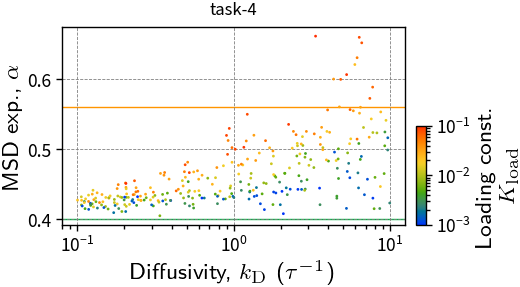

In [43]:
fig, ax = plt.subplots(figsize=(2.1, 1.5))

x_key = "extruder_diffusivity"
y_key = "msd_alpha"
z_key = "extruder_loading_constant"

sm = plt.cm.ScalarMappable(
    norm=get_norm(z_key),
    cmap=colorcet.m_rainbow,
)

section = metrics_table
x = section[x_key]
y = section[y_key]
z = section[z_key]
ax.scatter(x, y, c=z, s=1, norm=sm.norm, cmap=sm.cmap, zorder=3)

ax.axhline(0.56, ls="-", lw=0.5, color="C:y", zorder=1, label="fast")
ax.axhline(0.40, ls="-", lw=0.5, color="C:g", zorder=1, label="slow")

ax.grid(True, zorder=1)
ax.set_xscale("log")

cbar = attach_colorbar(ax, sm)
cbar.set_label(key_label.get(z_key, z_key), usetex=True)

ax.set_xlabel(key_label.get(x_key, x_key), usetex=True)
ax.set_ylabel(key_label.get(y_key, y_key), usetex=True)
ax.set_title(task_id, fontsize="small")

pass